In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
dataset_path = "iris.csv"

df = pd.read_csv(dataset_path, header=None, names=['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width', 'Species'])

X = df.iloc[:, :4].values
Y = df.iloc[:, 4].values

target_labels = np.unique(Y)

np.random.seed(42)
indices = np.random.permutation(len(X))

split = int(0.80 * len(X))
train_X, train_Y = X[indices[:split]], Y[indices[:split]]
test_X, test_Y = X[indices[split:]], Y[indices[split:]]

In [3]:
clf = RandomForestClassifier(criterion="entropy", min_samples_split=5)
clf.fit(train_X, train_Y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

In [4]:
y_pred = clf.predict(test_X)

accuracy = accuracy_score(y_pred, test_Y)
precision = precision_score(y_pred, test_Y, average="weighted")
recall = recall_score(y_pred, test_Y, average="weighted")
f1 = f1_score(y_pred, test_Y, average="weighted")

print("----Metrics----")
print("Average:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

----Metrics----
Average: 0.9666666666666667
Precision: 0.9694444444444444
Recall: 0.9666666666666667
F1: 0.9666666666666667


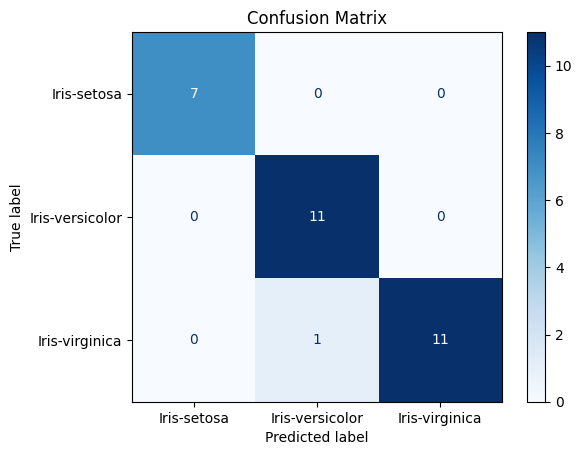

In [5]:
cm = confusion_matrix(test_Y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = target_labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [6]:
print("Enter sample data for prediction")

sl = float(input("Enter sample Sepal Length: "))
sw = float(input("Enter sample Sepal Width: "))
pl = float(input("Enter sample Petal Length: "))
pw = float(input("Enter sample Petal Width: "))

sample = np.array([[sl,sw,pl,pw]])
prediction = clf.predict(sample)

print(f"It is a {prediction[0]}")

Enter sample data for prediction


Enter sample Sepal Length:  3.2
Enter sample Sepal Width:  1.5
Enter sample Petal Length:  3.
Enter sample Petal Width:  1.


It is a Iris-versicolor
